In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import seaborn as sns
from scipy.stats import wasserstein_distance_nd
from multiprocessing import Pool
from itertools import combinations
import pyreadr
import geopandas as gpd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
from colorcet import palette
from matplotlib.colors import ListedColormap


az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

In [3]:
az.rcParams["plot.max_subplots"] = 200

In [24]:
# Read idata from netCDF file
idata_path = folder + "model_fits/a2_201601_201912[sigma_w_prior_halft]/idata/idata_[[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_10.0_sigma_w_nu_1.0].nc"


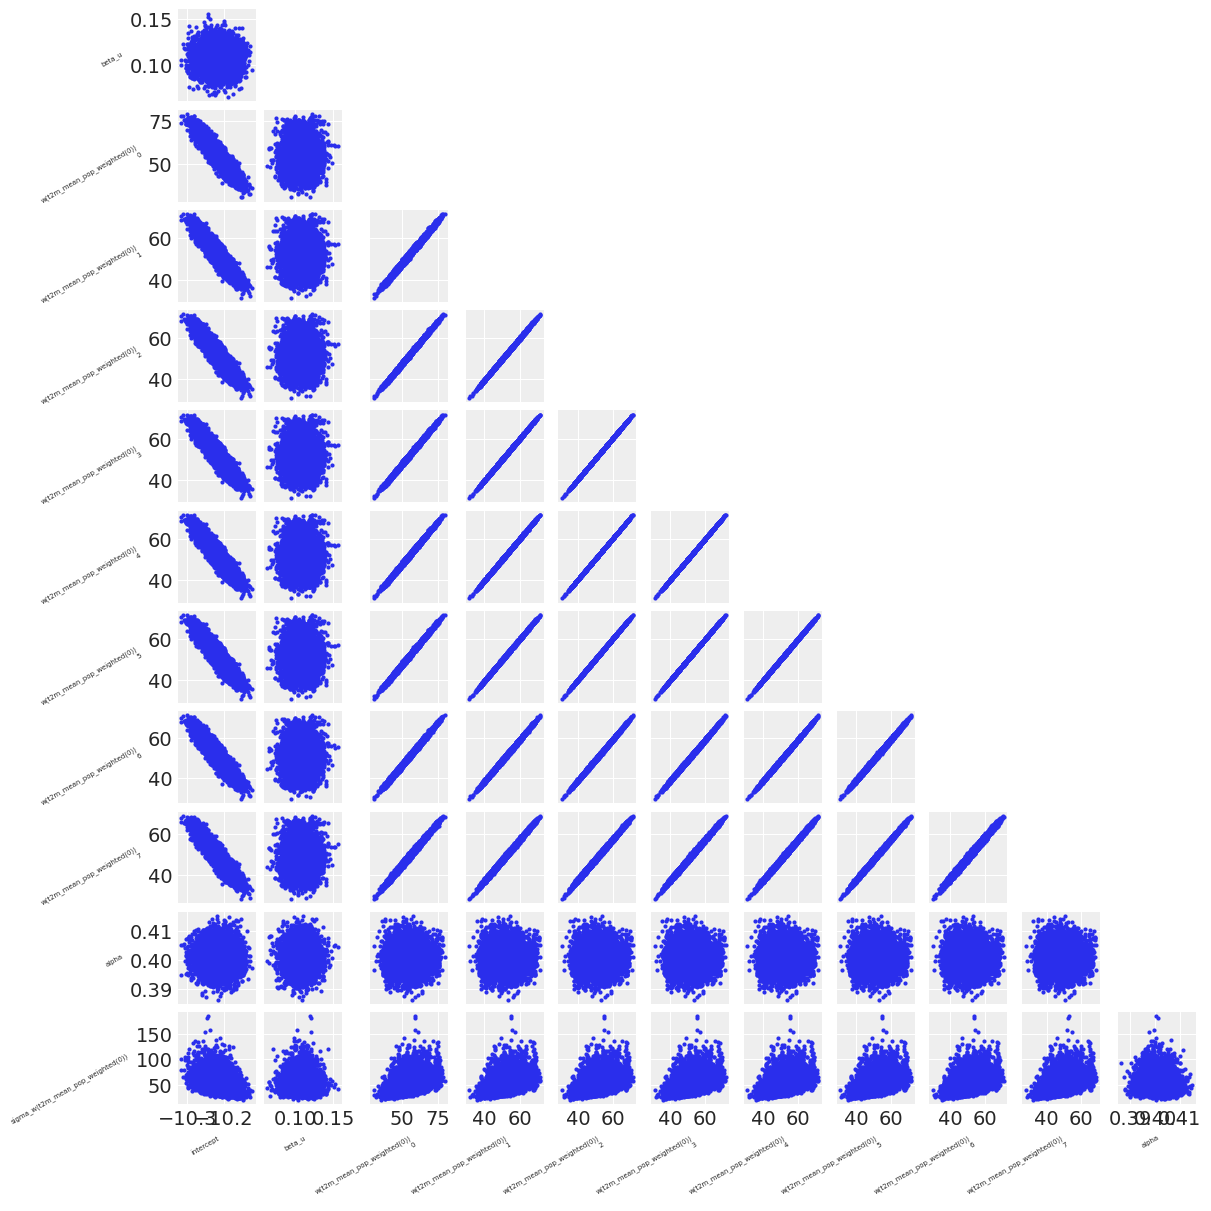

In [25]:
# "a2_201601_201912[sigma_w_prior]/idata/idata_[[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_5.0].nc"
idata = az.from_netcdf(idata_path)

# Plot pairplot of posterior samples
ax = az.plot_pair(
    idata,
    group="posterior",
    divergences=True,
    figsize=(12, 12),
    var_names=[v for v in idata.posterior.data_vars if not v.endswith("_")],
)
# fix axis labels and rotation
# rotate ticks on both axes
for i in range(ax.shape[0]):
    # Left-hand side (row labels / y-axis labels)
    ax[i, 0].yaxis.label.set_rotation(30)  # e.g., vertical left labels
    ax[i, 0].yaxis.label.set_fontsize(5)  # adjust font size if needed
    ax[i, 0].yaxis.label.set_ha('right')  # horizontal alignment

for j in range(ax.shape[1]):
    # Top (column labels / x-axis labels)
    ax[ax.shape[0]-1, j].xaxis.label.set_rotation(30)  # e.g., rotate top labels
    ax[ax.shape[0]-1, j].xaxis.label.set_fontsize(5)  # adjust font size if needed
    ax[ax.shape[0]-1, j].xaxis.label.set_ha('right')
plt.show()
plt.close()

In [ ]:
from _fitting.model_utils import compare_models
def collect_and_plot_outputs(base_folder, var_key, pars=["sigma_w_sigma", "sigma_w_nu"]):
    metrics_path = Path(base_folder) / "metrics"
    metric_dirs = [p for p in metrics_path.iterdir() if var_key in p.name]
    compare_df = compare_models(0, 0, 0, npz_files=[str(p) for p in metric_dirs])
    
    base_path = Path(base_folder) / "outputs"
    if not base_path.exists():
        raise FileNotFoundError(f"'outputs' folder not found in: {base_folder}")

    run_dirs = [p for p in base_path.iterdir()
                if p.is_dir() and var_key in p.name]
    if not run_dirs:
        raise ValueError(f"No subfolders containing '{var_key}' found in {base_path}")

    records = []
    loo_records = []

    for run_dir in run_dirs:
        # extract values of pars from folder name
        x_vals = {}
        for par in pars:
            try:
                # value is between _{par}_ and the next underscore after that
                x_vals[par] = run_dir.name.split(f"_{par}_")[1].split("_")[0]
            except Exception:
                x_vals[par] = run_dir.name

        summary_path = run_dir / "summary.csv"
        if summary_path.exists():
            summ = pd.read_csv(summary_path, index_col=0).rename(columns={"index": "var_name"})
            for var_name, row in summ.iterrows():
                records.append({
                    "x_vals": x_vals,
                    "var_name": var_name,
                    "mean": row.get("mean", np.nan),
                    "hdi_3%": row.get("hdi_3%", np.nan),
                    "hdi_97%": row.get("hdi_97%", np.nan),
                    "r_hat": row.get("r_hat", np.nan),
                })

        elpd_path = run_dir / "_model_elpd_metrics.csv"
        if elpd_path.exists():
            elpd = pd.read_csv(elpd_path)
            loo_val = elpd["loo"].iloc[0]
            loo_records.append({"x_vals": x_vals, "loo": loo_val})

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No summary.csv data found in matched subfolders.")
    
    if len(pars) == 1:
        par = pars[0]
        df["x"] = pd.to_numeric(df["x_vals"].apply(lambda d: d[par]))
        df = df.sort_values("x")

        loo_df = pd.DataFrame(loo_records)
        if not loo_df.empty:
            loo_df["x"] = pd.to_numeric(loo_df["x_vals"].apply(lambda d: d[par]))
            loo_df = loo_df.sort_values("x")

        for var_name, g in df.groupby("var_name"):
            x = g["x"].values
            mean = g["mean"].values
            hdi_low = g["hdi_3%"].values
            hdi_high = g["hdi_97%"].values
            rhat_bad = g["r_hat"].values >= 1.01

            plt.figure(figsize=(8, 4))
            plt.plot(x, mean, marker="o", label="mean")
            plt.fill_between(x, hdi_low, hdi_high, alpha=0.2, label="hdi 3%-97%")
            plt.scatter(x[rhat_bad], mean[rhat_bad], color="red", zorder=3, label="r_hat >= 1.01")
            plt.xticks(x, rotation=30)
            plt.title(var_name)
            plt.xlabel(par)
            plt.ylabel("value")
            plt.legend()
            plt.show()
            plt.close()

        # plot loo values if available
        if not loo_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(loo_df["x"], loo_df["loo"], marker="o", label="LOO")
            plt.xticks(loo_df["x"], rotation=30)
            plt.title("LOO values")
            plt.xlabel(par)
            plt.ylabel("LOO")
            plt.legend()
            plt.show()
            plt.close()

    elif len(pars) == 2:
        # just a normal plot, sort x values by the first and second par name and use the value pairs as x values and labels
        df["x"] = df["x_vals"].apply(lambda d: (d[pars[0]], d[pars[1]]))
        df = df.sort_values("x")

        loo_df = pd.DataFrame(loo_records)
        if not loo_df.empty:
            loo_df["x"] = pd.to_numeric(loo_df["x_vals"].apply(lambda d: (d[pars[0]], d[pars[1]])))
            loo_df = loo_df.sort_values("x")

        for var_name, g in df.groupby("var_name"):
            x = g["x"].values
            mean = g["mean"].values
            hdi_low = g["hdi_3%"].values
            hdi_high = g["hdi_97%"].values
            rhat_bad = g["r_hat"].values >= 1.01

            plt.figure(figsize=(8, 4))
            plt.plot(range(len(x)), mean, marker="o", label="mean")
            plt.fill_between(range(len(x)), hdi_low, hdi_high, alpha=0.2, label="hdi 3%-97%")
            plt.scatter(np.array(range(len(x)))[rhat_bad], mean[rhat_bad], color="red", zorder=3, label="r_hat >= 1.01")
            plt.xticks(range(len(x)), [f"({a}, {b})" for a, b in x], rotation=30)
            plt.title(var_name)
            plt.xlabel(f"{pars[0]} & {pars[1]}")
            plt.ylabel("value")
            plt.legend()
            plt.show()
            plt.close()
        
        # plot loo values if available
        if not loo_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(range(len(x)), loo_df["loo"], marker="o", label="LOO")
            plt.xticks(range(len(x)), [f"({a}, {b})" for a, b in x], rotation=30)
            plt.title("LOO values")
            plt.xlabel(f"{pars[0]} & {pars[1]}")
            plt.ylabel("LOO")
            plt.legend()
            plt.show()
            plt.close()

    return df, loo_df, compare_df

In [ ]:
from _fitting.model_utils import compare_models
def collect_and_plot_outputs(base_folder, var_key, pars=["sigma_w_sigma", "sigma_w_nu"]):
    metrics_path = Path(base_folder) / "metrics"
    metric_dirs = [p for p in metrics_path.iterdir() if var_key in p.name]
    compare_df = compare_models(0, 0, 0, npz_files=[str(p) for p in metric_dirs])
    
    base_path = Path(base_folder) / "outputs"
    if not base_path.exists():
        raise FileNotFoundError(f"'outputs' folder not found in: {base_folder}")

    run_dirs = [p for p in base_path.iterdir()
                if p.is_dir() and var_key in p.name]
    if not run_dirs:
        raise ValueError(f"No subfolders containing '{var_key}' found in {base_path}")

    records = []
    loo_records = []

    for run_dir in run_dirs:
        # extract values of pars from folder name
        x_vals = {}
        for par in pars:
            try:
                # value is between _{par}_ and the next underscore after that
                x_vals[par] = run_dir.name.split(f"_{par}_")[1].split("_")[0]
            except Exception:
                x_vals[par] = run_dir.name

        summary_path = run_dir / "summary.csv"
        if summary_path.exists():
            summ = pd.read_csv(summary_path, index_col=0).rename(columns={"index": "var_name"})
            for var_name, row in summ.iterrows():
                records.append({
                    "x_vals": x_vals,
                    "var_name": var_name,
                    "mean": row.get("mean", np.nan),
                    "hdi_3%": row.get("hdi_3%", np.nan),
                    "hdi_97%": row.get("hdi_97%", np.nan),
                    "r_hat": row.get("r_hat", np.nan),
                })

        elpd_path = run_dir / "_model_elpd_metrics.csv"
        if elpd_path.exists():
            elpd = pd.read_csv(elpd_path)
            loo_val = elpd["loo"].iloc[0]
            loo_records.append({"x_vals": x_vals, "loo": loo_val})

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No summary.csv data found in matched subfolders.")
    
    if len(pars) == 1:
        par = pars[0]
        df["x"] = pd.to_numeric(df["x_vals"].apply(lambda d: d[par]))
        df = df.sort_values("x")

        loo_df = pd.DataFrame(loo_records)
        if not loo_df.empty:
            loo_df["x"] = pd.to_numeric(loo_df["x_vals"].apply(lambda d: d[par]))
            loo_df = loo_df.sort_values("x")

        for var_name, g in df.groupby("var_name"):
            x = g["x"].values
            mean = g["mean"].values
            hdi_low = g["hdi_3%"].values
            hdi_high = g["hdi_97%"].values
            rhat_bad = g["r_hat"].values >= 1.01

            plt.figure(figsize=(8, 4))
            plt.plot(x, mean, marker="o", label="mean")
            plt.fill_between(x, hdi_low, hdi_high, alpha=0.2, label="hdi 3%-97%")
            plt.scatter(x[rhat_bad], mean[rhat_bad], color="red", zorder=3, label="r_hat >= 1.01")
            plt.xticks(x, rotation=30)
            plt.title(var_name)
            plt.xlabel(par)
            plt.ylabel("value")
            plt.legend()
            plt.show()
            plt.close()

        # plot loo values if available
        if not loo_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(loo_df["x"], loo_df["loo"], marker="o", label="LOO")
            plt.xticks(loo_df["x"], rotation=30)
            plt.title("LOO values")
            plt.xlabel(par)
            plt.ylabel("LOO")
            plt.legend()
            plt.show()
            plt.close()

    elif len(pars) == 2:
        # just a normal plot, sort x values by the first and second par name and use the value pairs as x values and labels
        df["x"] = df["x_vals"].apply(lambda d: (d[pars[0]], d[pars[1]]))
        df = df.sort_values("x")

        loo_df = pd.DataFrame(loo_records)
        if not loo_df.empty:
            loo_df["x"] = pd.to_numeric(loo_df["x_vals"].apply(lambda d: (d[pars[0]], d[pars[1]])))
            loo_df = loo_df.sort_values("x")

        for var_name, g in df.groupby("var_name"):
            x = g["x"].values
            mean = g["mean"].values
            hdi_low = g["hdi_3%"].values
            hdi_high = g["hdi_97%"].values
            rhat_bad = g["r_hat"].values >= 1.01

            plt.figure(figsize=(8, 4))
            plt.plot(range(len(x)), mean, marker="o", label="mean")
            plt.fill_between(range(len(x)), hdi_low, hdi_high, alpha=0.2, label="hdi 3%-97%")
            plt.scatter(np.array(range(len(x)))[rhat_bad], mean[rhat_bad], color="red", zorder=3, label="r_hat >= 1.01")
            plt.xticks(range(len(x)), [f"({a}, {b})" for a, b in x], rotation=30)
            plt.title(var_name)
            plt.xlabel(f"{pars[0]} & {pars[1]}")
            plt.ylabel("value")
            plt.legend()
            plt.show()
            plt.close()
        
        # plot loo values if available
        if not loo_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(range(len(x)), loo_df["loo"], marker="o", label="LOO")
            plt.xticks(range(len(x)), [f"({a}, {b})" for a, b in x], rotation=30)
            plt.title("LOO values")
            plt.xlabel(f"{pars[0]} & {pars[1]}")
            plt.ylabel("LOO")
            plt.legend()
            plt.show()
            plt.close()

    return df, loo_df, compare_df, figs

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from _fitting.model_utils import compare_models

def collect_and_plot_outputs(base_folder, var_key, pars=["sigma_w_sigma", "sigma_w_nu"]):
    metrics_path = Path(base_folder) / "metrics"
    metric_dirs = [p for p in metrics_path.iterdir() if var_key in p.name]
    compare_df = compare_models(0, 0, 0, npz_files=[str(p) for p in metric_dirs])
    
    base_path = Path(base_folder) / "outputs"
    if not base_path.exists():
        raise FileNotFoundError(f"'outputs' folder not found in: {base_folder}")

    run_dirs = [p for p in base_path.iterdir()
                if p.is_dir() and var_key in p.name]
    if not run_dirs:
        raise ValueError(f"No subfolders containing '{var_key}' found in {base_path}")

    records = []
    loo_records = []

    for run_dir in run_dirs:
        # extract values of pars from folder name
        x_vals = {}
        for par in pars:
            try:
                x_vals[par] = run_dir.name.split(f"_{par}_")[1].split("_")[0]
            except Exception:
                x_vals[par] = run_dir.name

        summary_path = run_dir / "summary.csv"
        if summary_path.exists():
            summ = pd.read_csv(summary_path, index_col=0).rename(columns={"index": "var_name"})
            for var_name, row in summ.iterrows():
                records.append({
                    "x_vals": x_vals,
                    "var_name": var_name,
                    "mean": row.get("mean", np.nan),
                    "hdi_3%": row.get("hdi_3%", np.nan),
                    "hdi_97%": row.get("hdi_97%", np.nan),
                    "r_hat": row.get("r_hat", np.nan),
                })

        elpd_path = run_dir / "_model_elpd_metrics.csv"
        if elpd_path.exists():
            elpd = pd.read_csv(elpd_path)
            loo_val = elpd["loo"].iloc[0]
            loo_records.append({"x_vals": x_vals, "loo": loo_val})

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No summary.csv data found in matched subfolders.")
    
    figs = []  # store all figures

    if len(pars) == 1:
        par = pars[0]
        df["x"] = pd.to_numeric(df["x_vals"].apply(lambda d: d[par]))
        df = df.sort_values("x")

        loo_df = pd.DataFrame(loo_records)
        if not loo_df.empty:
            loo_df["x"] = pd.to_numeric(loo_df["x_vals"].apply(lambda d: d[par]))
            loo_df = loo_df.sort_values("x")

        for var_name, g in df.groupby("var_name"):
            x = g["x"].values
            mean = g["mean"].values
            hdi_low = g["hdi_3%"].values
            hdi_high = g["hdi_97%"].values
            rhat_bad = g["r_hat"].values >= 1.01

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(x, mean, marker="o", label="mean")
            ax.fill_between(x, hdi_low, hdi_high, alpha=0.2, label="hdi 3%-97%")
            ax.scatter(x[rhat_bad], mean[rhat_bad], color="red", zorder=3, label="r_hat >= 1.01")
            ax.set_xticks(x)
            ax.set_xticklabels(x, rotation=30)
            ax.set_title(var_name)
            ax.set_xlabel(par)
            ax.set_ylabel("value")
            ax.legend()
            figs.append(fig)
            plt.close(fig)

        if not loo_df.empty:
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(loo_df["x"], loo_df["loo"], marker="o", label="LOO")
            ax.set_xticks(loo_df["x"])
            ax.set_xticklabels(loo_df["x"], rotation=30)
            ax.set_title("LOO values")
            ax.set_xlabel(par)
            ax.set_ylabel("LOO")
            ax.legend()
            figs.append(fig)
            plt.close(fig)

    elif len(pars) == 2:
        p1, p2 = pars
        df["x"] = df["x_vals"].apply(lambda d: (float(d[p1]), float(d[p2])))
        df = df.sort_values("x")

        loo_df = pd.DataFrame(loo_records)
        if not loo_df.empty:
            loo_df["x"] = loo_df["x_vals"].apply(lambda d: (float(d[p1]), float(d[p2])))
            loo_df = loo_df.sort_values("x")

        for var_name, g in df.groupby("var_name"):
            x = g["x"].values
            mean = g["mean"].values
            hdi_low = g["hdi_3%"].values
            hdi_high = g["hdi_97%"].values
            rhat_bad = g["r_hat"].values >= 1.01
            idx = np.arange(len(x))

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(idx, mean, marker="o", label="mean")
            ax.fill_between(idx, hdi_low, hdi_high, alpha=0.2, label="hdi 3%-97%")
            ax.scatter(idx[rhat_bad], mean[rhat_bad], color="red", zorder=3, label="r_hat >= 1.01")
            ax.set_xticks(idx)
            ax.set_xticklabels([f"({a}, {b})" for a, b in x], rotation=30)
            ax.set_title(var_name)
            ax.set_xlabel(f"{p1} & {p2}")
            ax.set_ylabel("value")
            ax.legend()
            figs.append(fig)
            plt.close(fig)

        if not loo_df.empty:
            x = loo_df["x"].values
            idx = np.arange(len(x))
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(idx, loo_df["loo"].values, marker="o", label="LOO")
            ax.set_xticks(idx)
            ax.set_xticklabels([f"({a}, {b})" for a, b in x], rotation=30)
            ax.set_title("LOO values")
            ax.set_xlabel(f"{p1} & {p2}")
            ax.set_ylabel("LOO")
            ax.legend()
            figs.append(fig)
            plt.close(fig)

    return df, loo_df, compare_df, figs


,rank,loo,p_loo,dloo,weight,loo_se,dse
model,,,,,,,
[nosurv__urb_p_std][nostat][]_intercept_sigma_2.5,0,-83129.40,24107,0.00,0.21,315.92,0.00
[nosurv__urb_p_std][nostat][]_intercept_sigma_1.0,1,-83129.45,24107,0.05,0.20,315.92,0.02
[nosurv__urb_p_std][nostat][]_intercept_sigma_10.0,2,-83129.45,24107,0.05,0.20,315.90,0.01
[nosurv__urb_p_std][nostat][]_intercept_sigma_0.5,3,-83129.48,24107,0.07,0.20,315.91,0.02
[nosurv__urb_p_std][nostat][]_intercept_sigma_5.0,4,-83129.48,24107,0.08,0.20,315.91,0.01


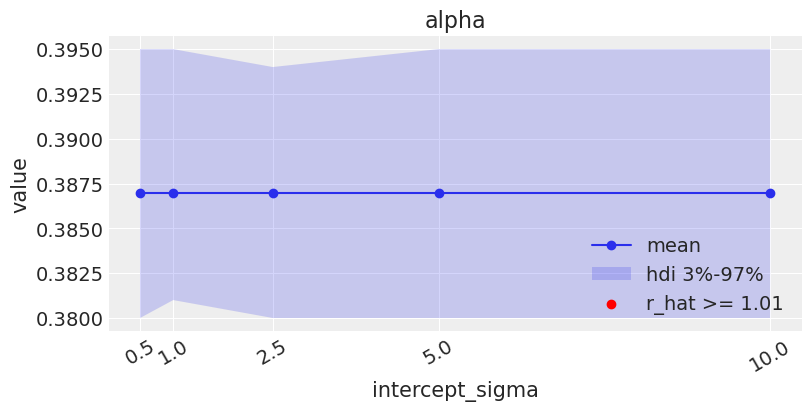

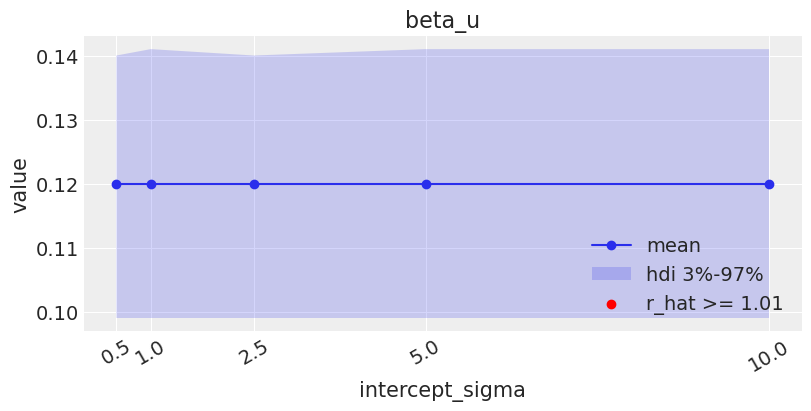

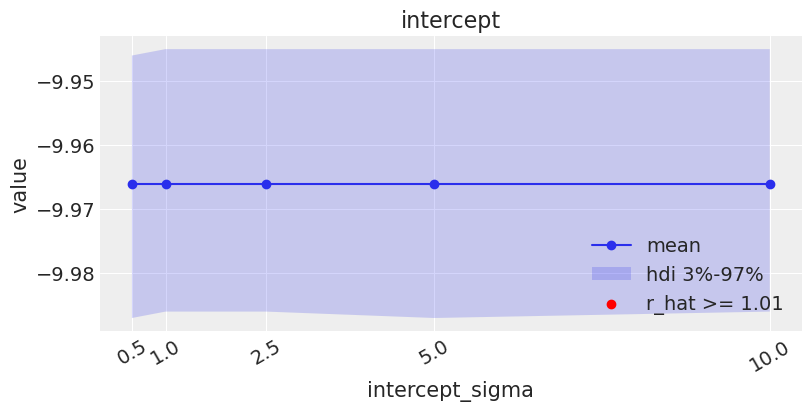

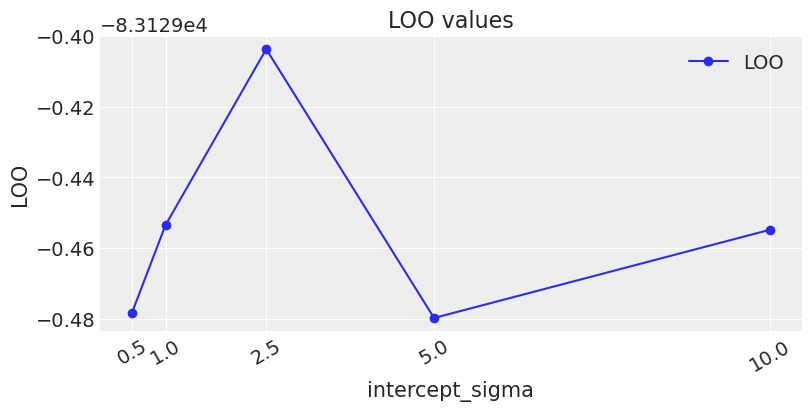

In [25]:
df, loo_df, compare_df, figs = collect_and_plot_outputs(folder + "model_fits/a2_201601_201912[intercept_prior](intercept_mean_-10,sd_1.0)/","", pars=["intercept_sigma"])
display(compare_df)
for fig in figs:
    display(fig)

,rank,loo,p_loo,dloo,weight,loo_se,dse
model,,,,,,,
[nosurv__urb_p_std][nostat][]_beta_u_sigma_0.1,0,-83129.42,24107,0.00,0.13,315.85,0.00
[nosurv__urb_p_std][nostat][]_beta_u_sigma_0.25,1,-83129.46,24107,0.04,0.13,315.90,0.18
[nosurv__urb_p_std][nostat][]_beta_u_sigma_1.5,2,-83129.47,24107,0.04,0.13,315.90,0.19
[nosurv__urb_p_std][nostat][]_beta_u_sigma_1.0,3,-83129.48,24107,0.06,0.12,315.90,0.20
[nosurv__urb_p_std][nostat][]_beta_u_sigma_0.5,4,-83129.48,24107,0.06,0.12,315.90,0.18
[nosurv__urb_p_std][nostat][]_beta_u_sigma_5.0,5,-83129.49,24107,0.07,0.12,315.91,0.19
[nosurv__urb_p_std][nostat][]_beta_u_sigma_2.5,6,-83129.50,24107,0.08,0.12,315.91,0.19
[nosurv__urb_p_std][nostat][]_beta_u_sigma_2.0,7,-83129.51,24107,0.09,0.12,315.91,0.20


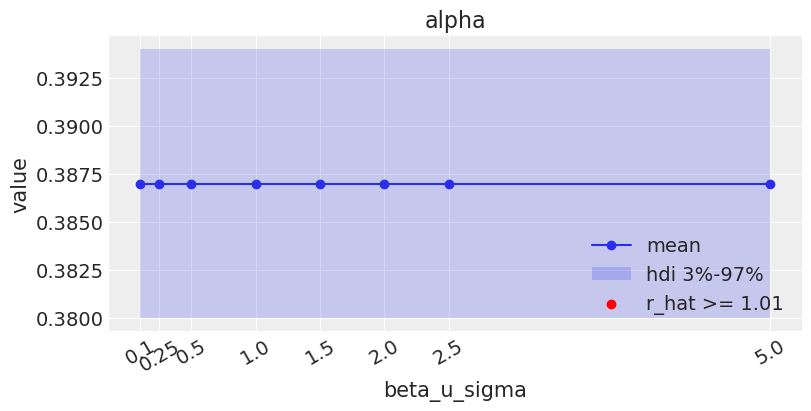

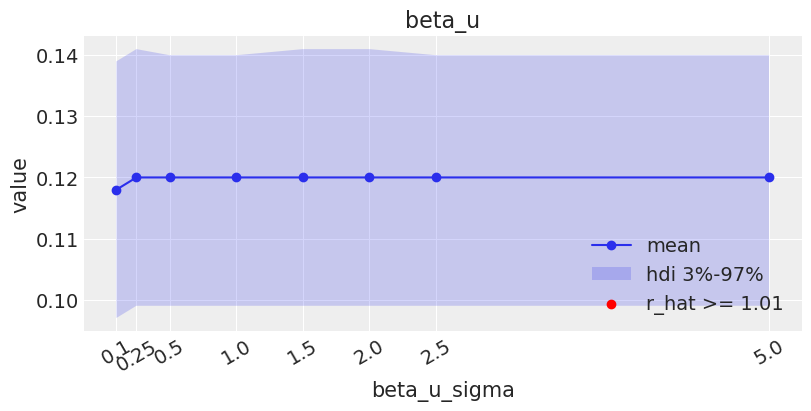

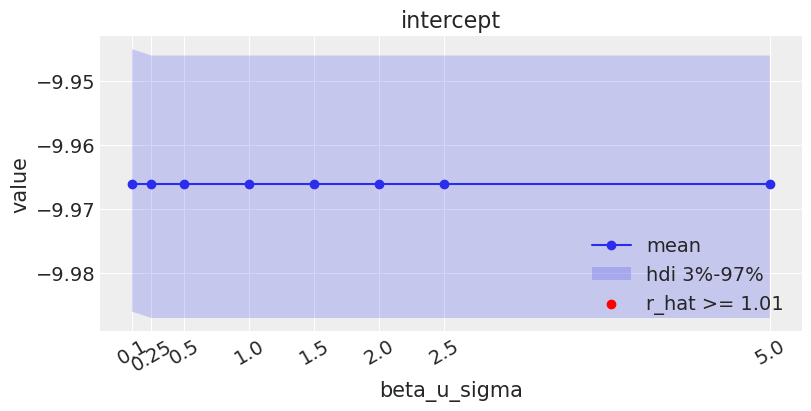

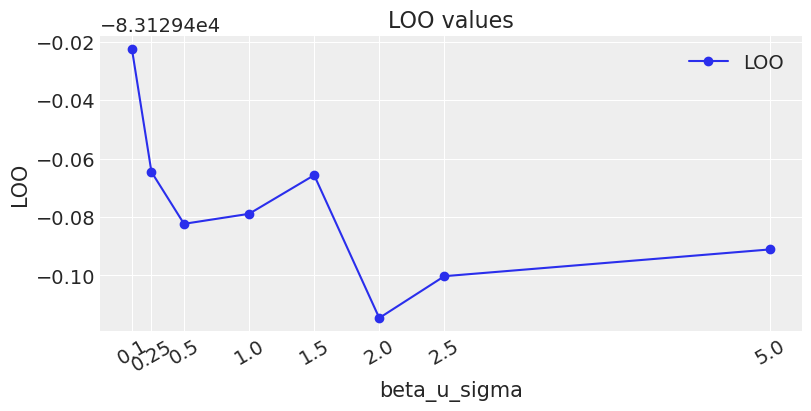

In [26]:
df, loo_df, compare_df, figs = collect_and_plot_outputs(folder + "model_fits/a2_201601_201912[beta_u_prior]/","", pars=["beta_u_sigma"])
display(compare_df)
for fig in figs:
    display(fig)

,rank,loo,p_loo,dloo,weight,loo_se,dse
model,,,,,,,
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_5.0",0,-82392.03,24107,0.00,0.12,315.18,0.00
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_3.0",1,-82392.09,24107,0.06,0.12,315.19,0.07
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_5.0",2,-82392.15,24107,0.12,0.11,315.17,0.17
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_3.0",3,-82392.17,24107,0.15,0.11,315.18,0.18
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_1.0",4,-82392.18,24107,0.15,0.11,315.18,0.20
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_3.0",5,-82392.22,24107,0.20,0.11,315.19,0.30
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_5.0",6,-82392.29,24107,0.27,0.11,315.18,0.27
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_1.0",7,-82392.32,24107,0.29,0.10,315.18,0.14
"[nosurv__urb_p_std][rh_mean_p(0)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_1.0",8,-82392.32,24107,0.30,0.10,315.19,0.26


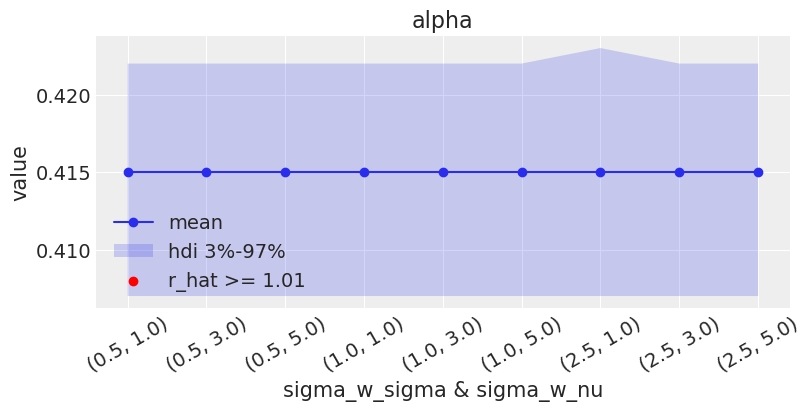

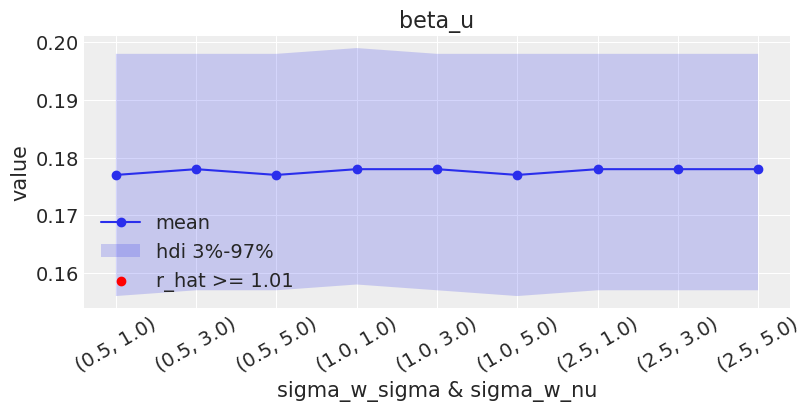

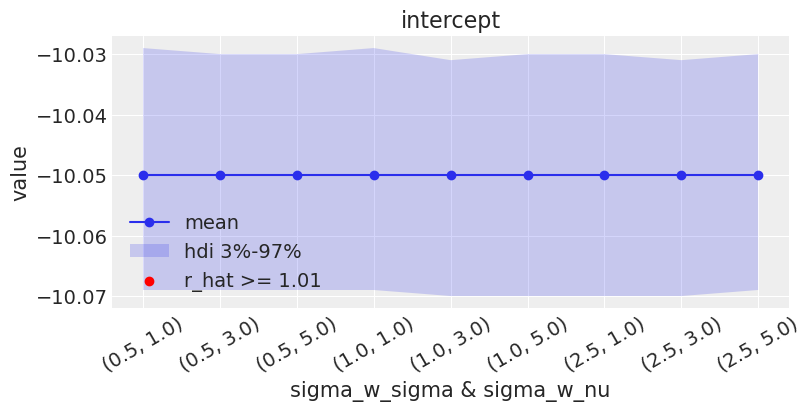

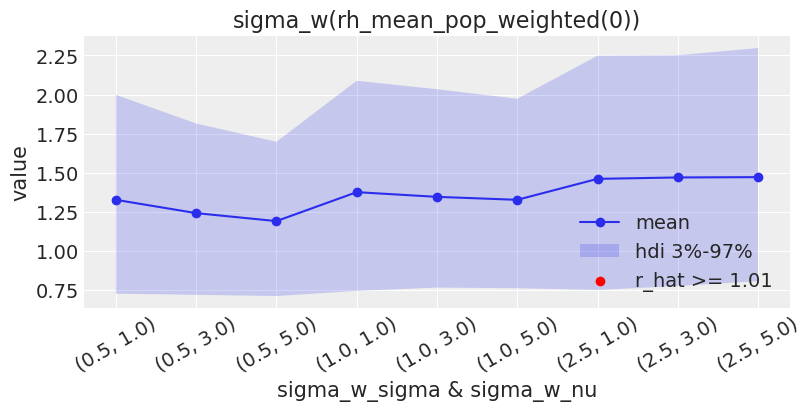

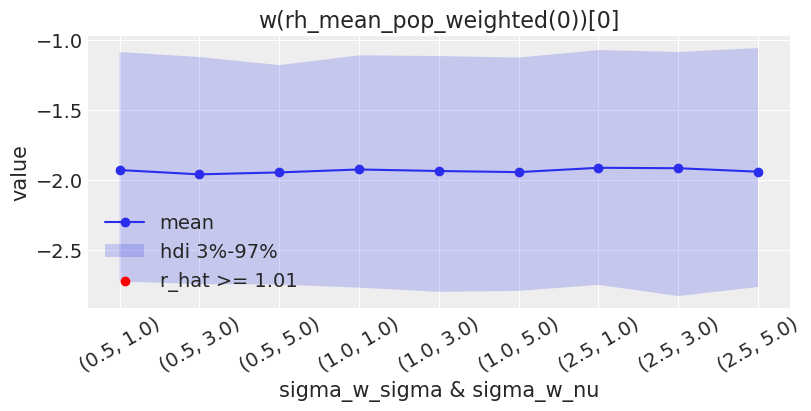

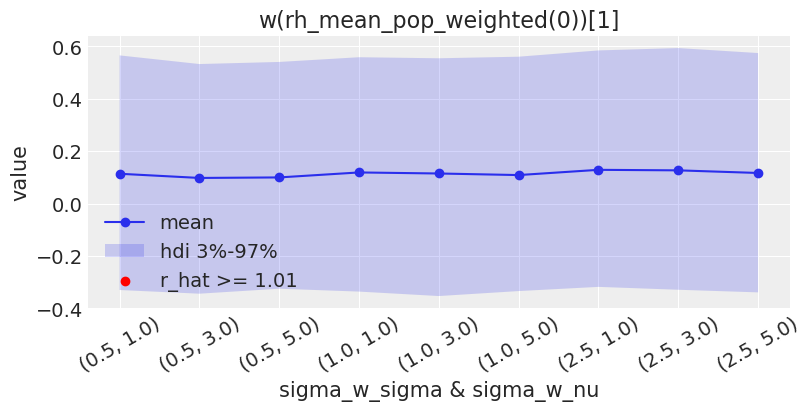

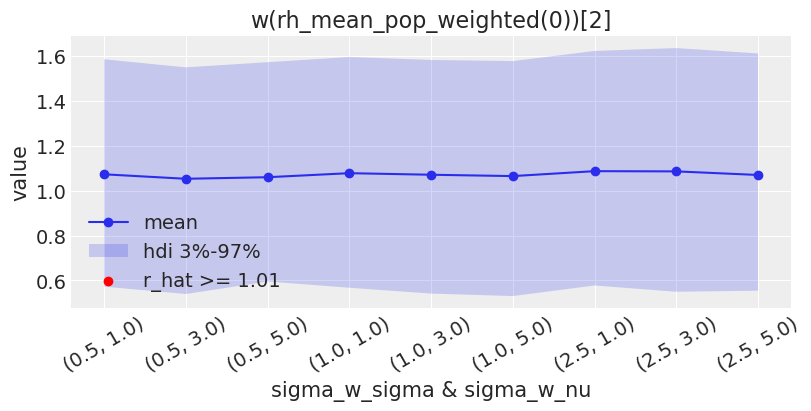

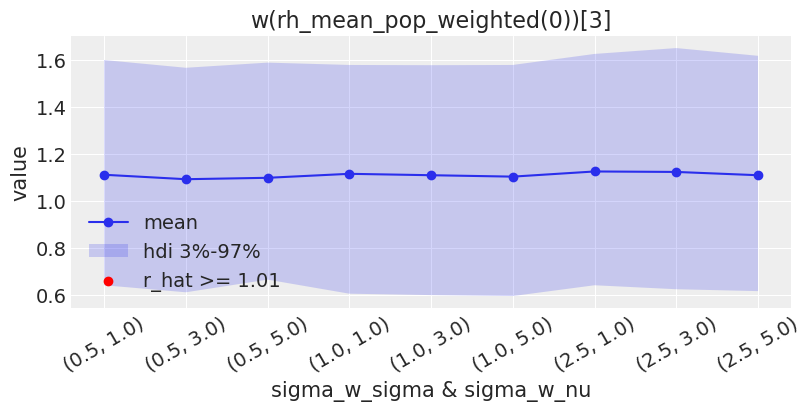

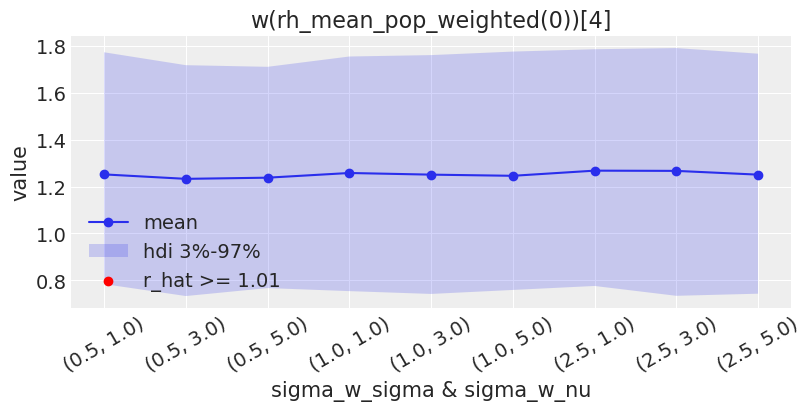

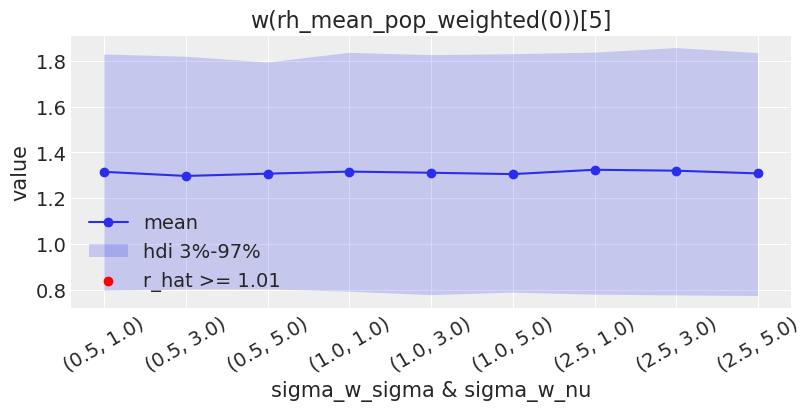

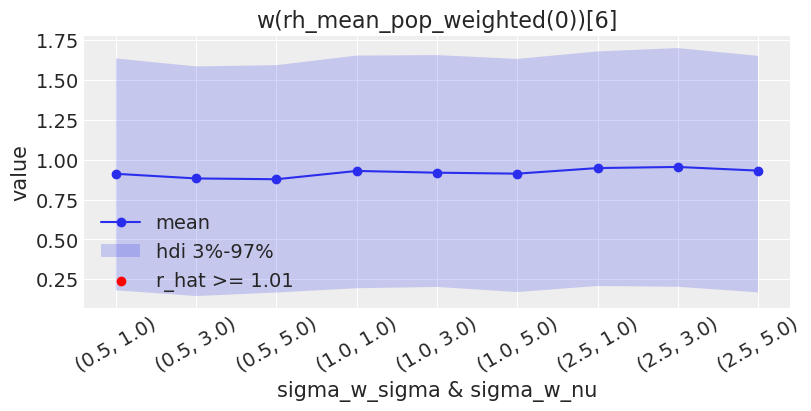

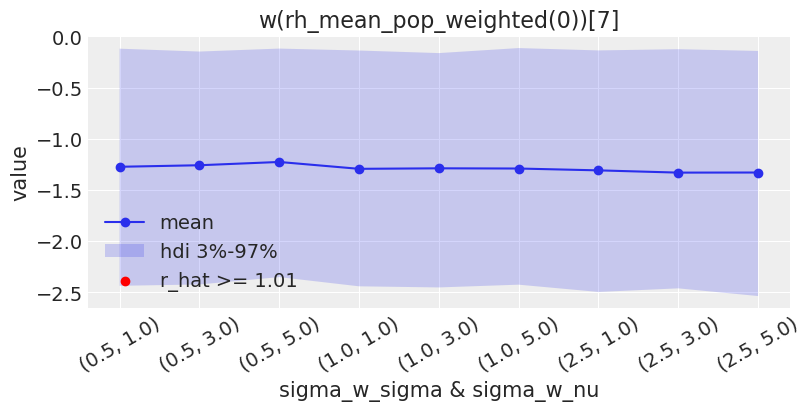

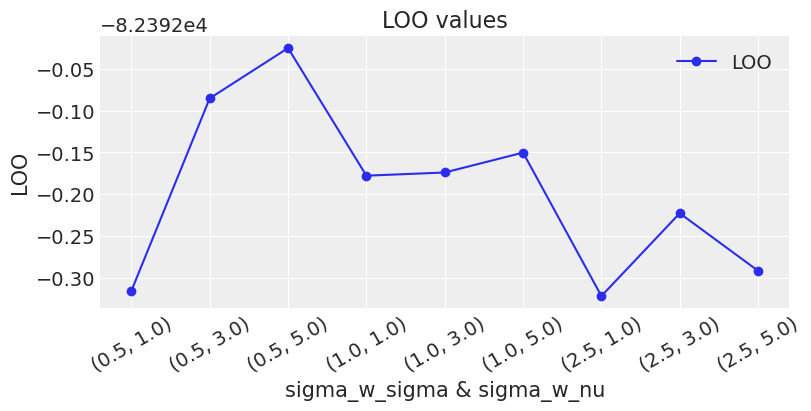

In [28]:
df, loo_df, compare_df, figs = collect_and_plot_outputs(folder + "model_fits/a2_201601_201912[sigma_w_prior_halft]/", "rh", pars=["sigma_w_sigma", "sigma_w_nu"])
display(compare_df)
for fig in figs:
    display(fig)

,rank,loo,p_loo,dloo,weight,loo_se,dse
model,,,,,,,
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_5.0",0,-82268.14,24107,0.00,0.12,314.55,0.00
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_5.0",1,-82268.18,24107,0.04,0.12,314.55,0.30
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_1.0",2,-82268.21,24107,0.07,0.12,314.55,0.14
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_1.0",3,-82268.29,24107,0.15,0.11,314.54,0.22
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_3.0",4,-82268.31,24107,0.17,0.11,314.54,0.07
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_3.0",5,-82268.33,24107,0.19,0.11,314.54,0.32
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_3.0",6,-82268.36,24107,0.22,0.11,314.56,0.19
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_1.0",7,-82268.38,24107,0.24,0.11,314.55,0.31
"[nosurv__urb_p_std][tp_24hmean_log_p(1)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_5.0",8,-82268.40,24107,0.26,0.11,314.54,0.21


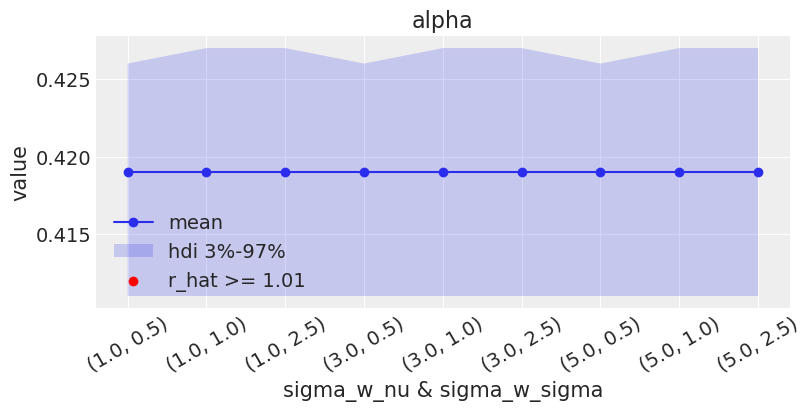

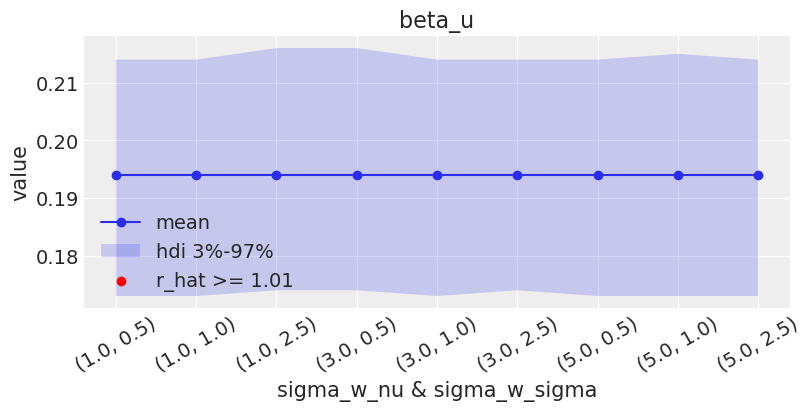

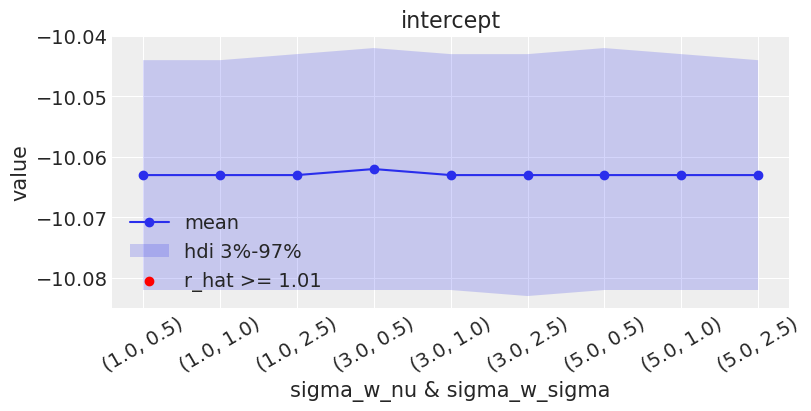

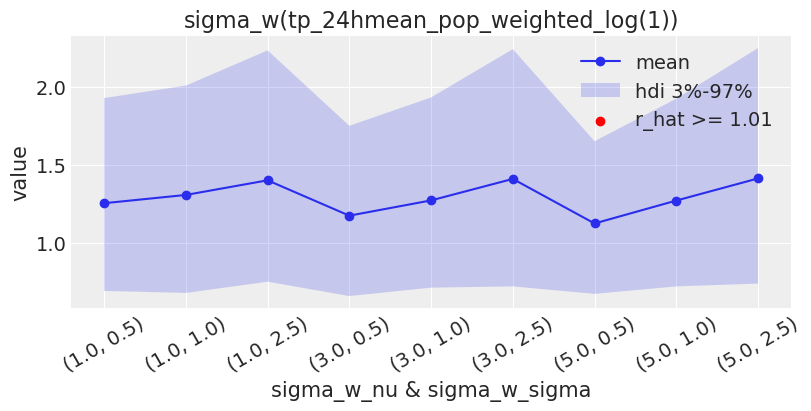

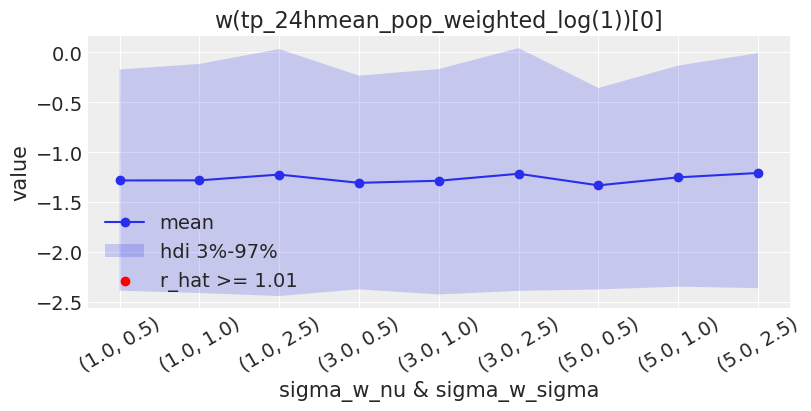

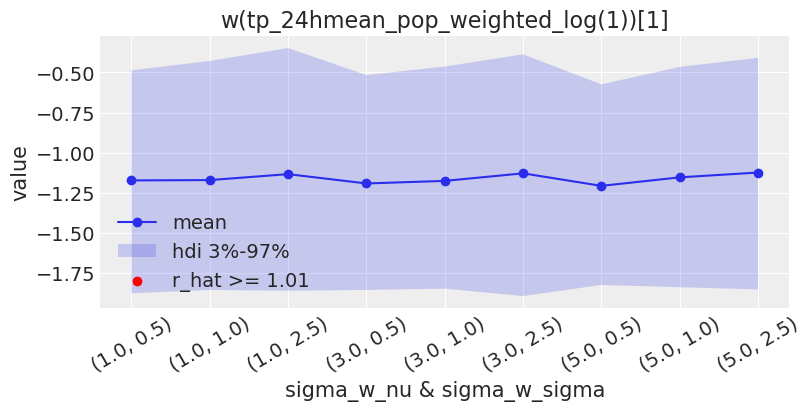

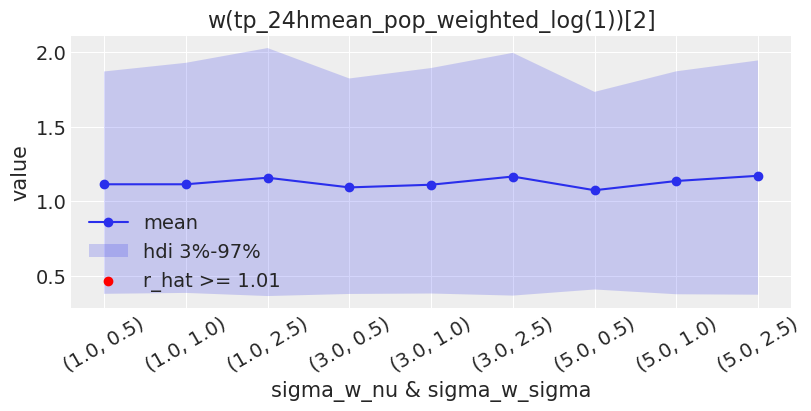

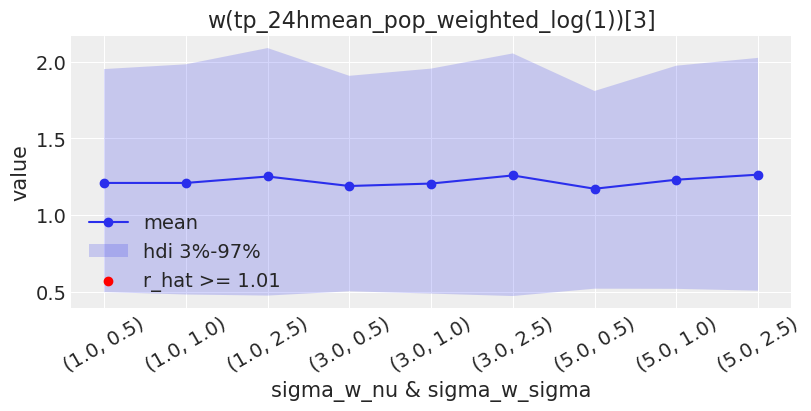

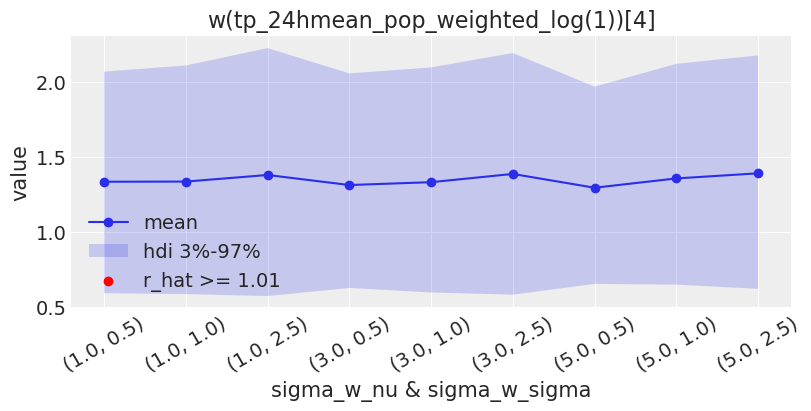

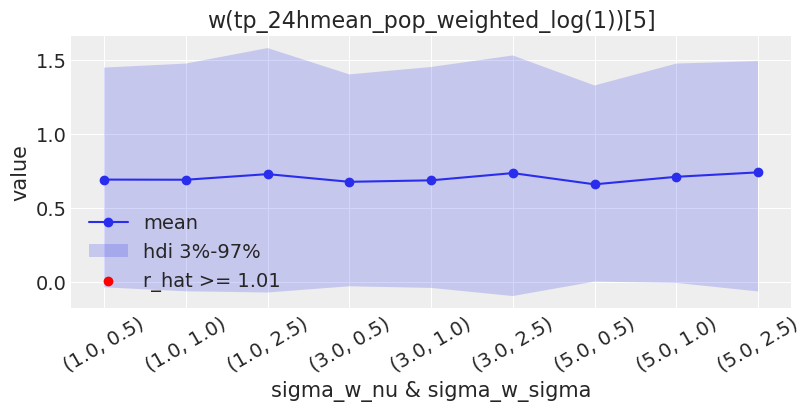

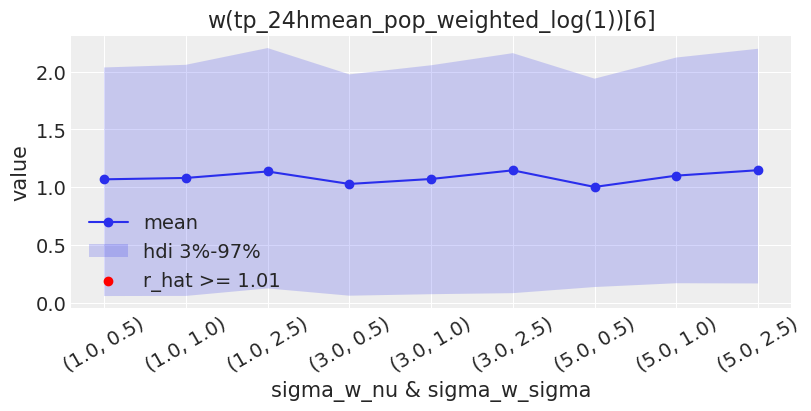

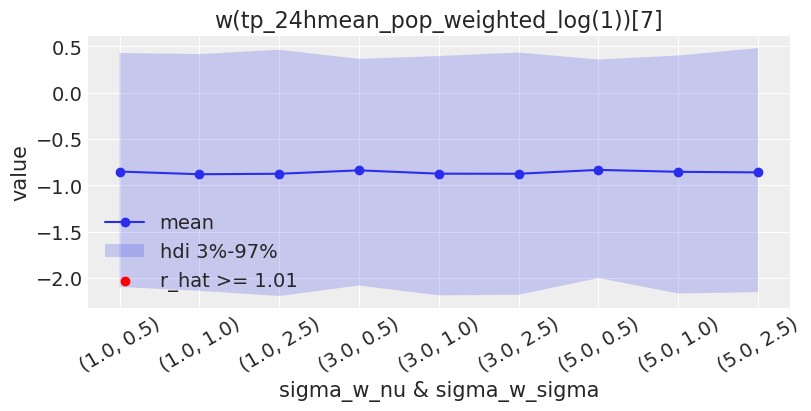

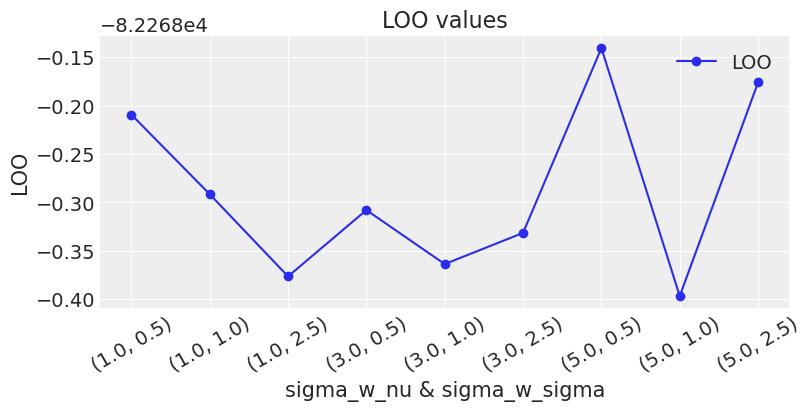

In [29]:
df, loo_df, compare_df, figs = collect_and_plot_outputs(folder + "model_fits/a2_201601_201912[sigma_w_prior_halft]/", "tp_24hmean_log_p(1)", pars=["sigma_w_nu", "sigma_w_sigma"])
display(compare_df)
for fig in figs:
    display(fig)

,rank,loo,p_loo,dloo,weight,loo_se,dse
model,,,,,,,
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_3.0",0,-82526.72,24107,0.00,0.17,312.80,0.00
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_5.0",1,-82526.74,24107,0.02,0.17,312.80,0.08
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_1.0",2,-82526.87,24107,0.15,0.16,312.80,0.07
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_1.0",3,-82527.48,24107,0.76,0.12,312.79,0.32
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_1.0",4,-82527.68,24107,0.96,0.11,312.79,0.46
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_3.0",5,-82527.96,24107,1.24,0.09,312.79,0.63
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_5.0",6,-82527.97,24107,1.25,0.09,312.77,0.74
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_3.0",7,-82528.78,24107,2.06,0.06,312.79,1.06
"[nosurv__urb_p_std][tp_24hmean_log_p(5)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_5.0",8,-82529.72,24107,3.00,0.04,312.80,1.51


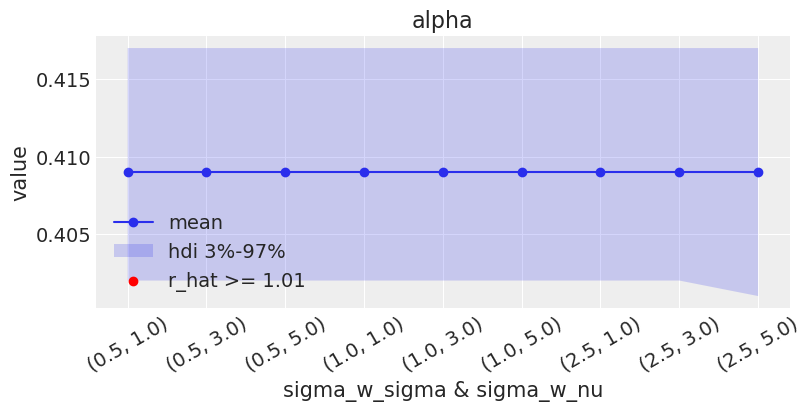

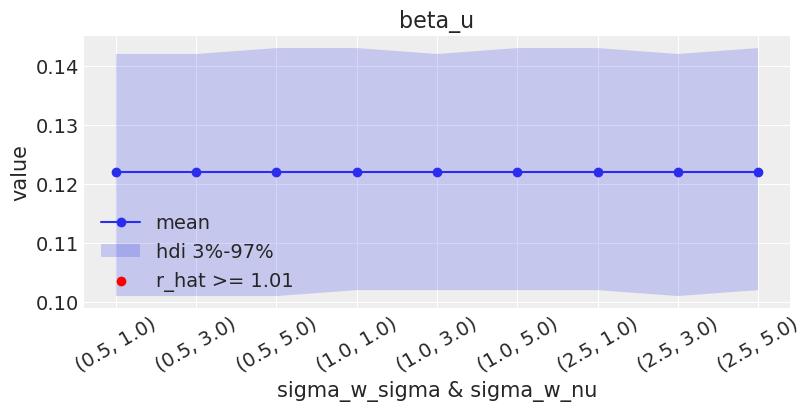

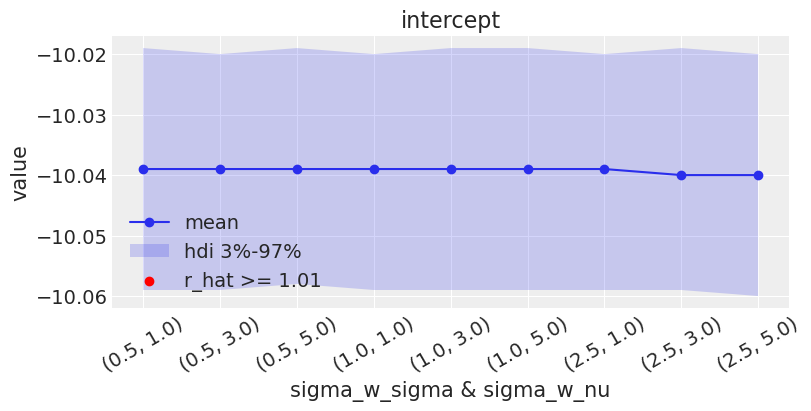

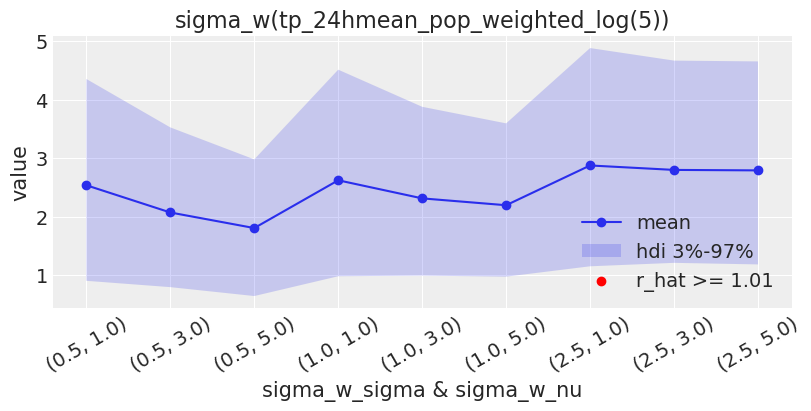

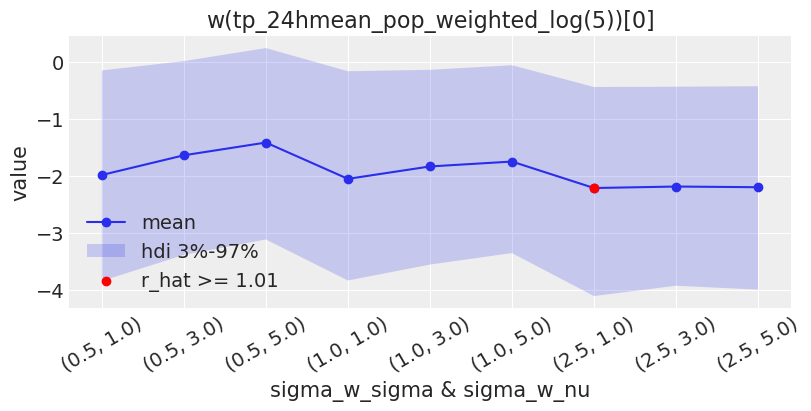

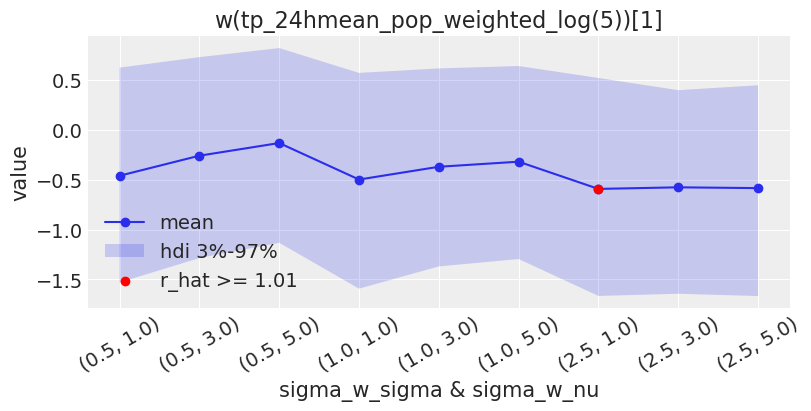

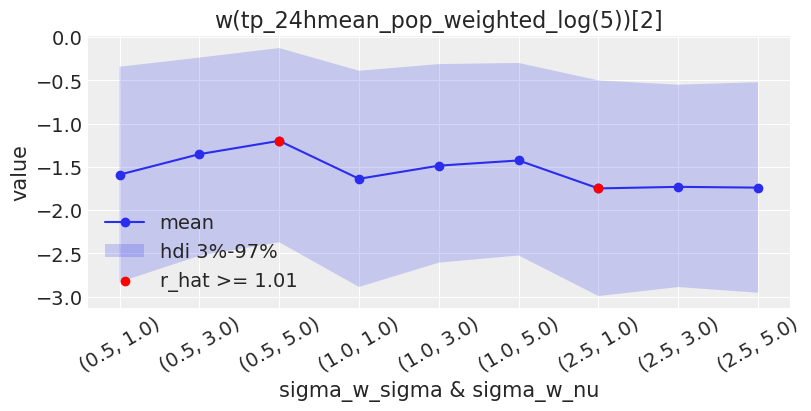

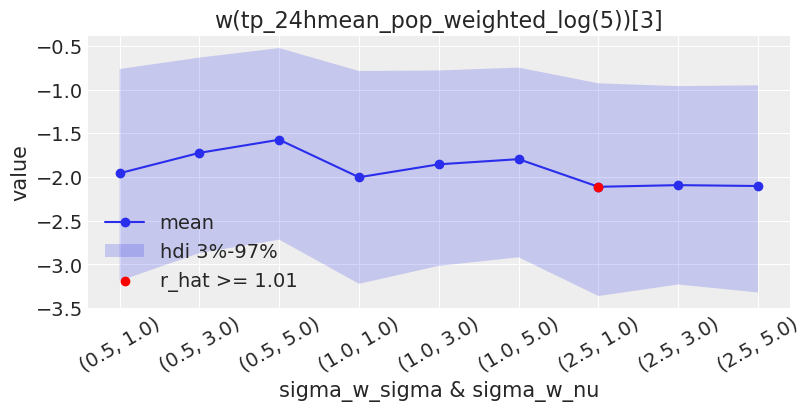

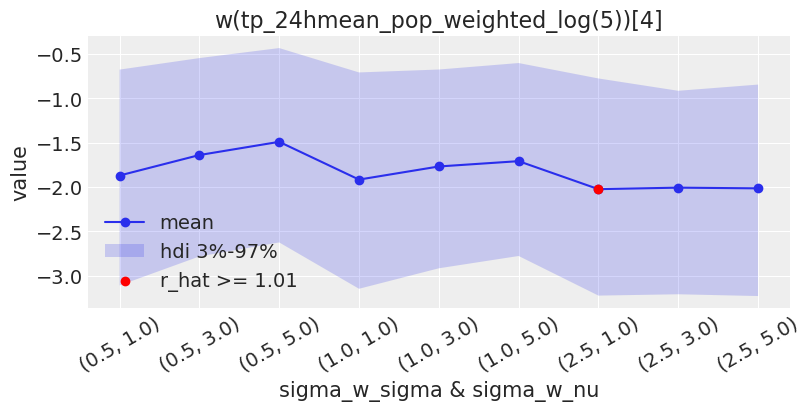

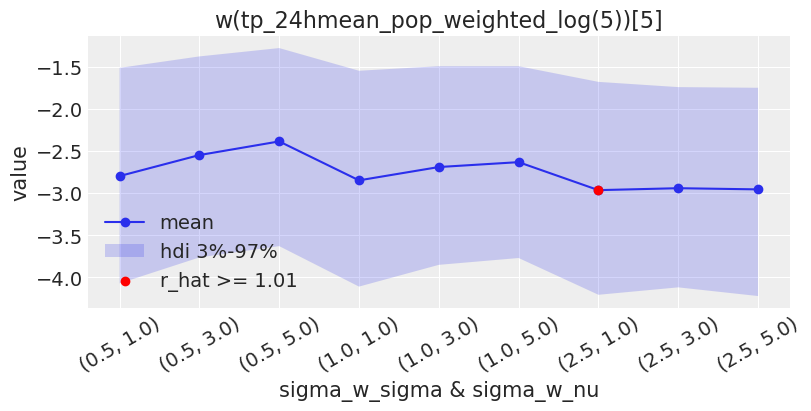

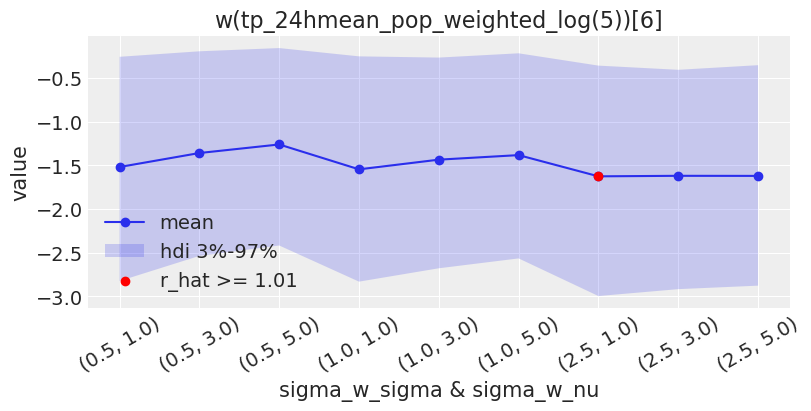

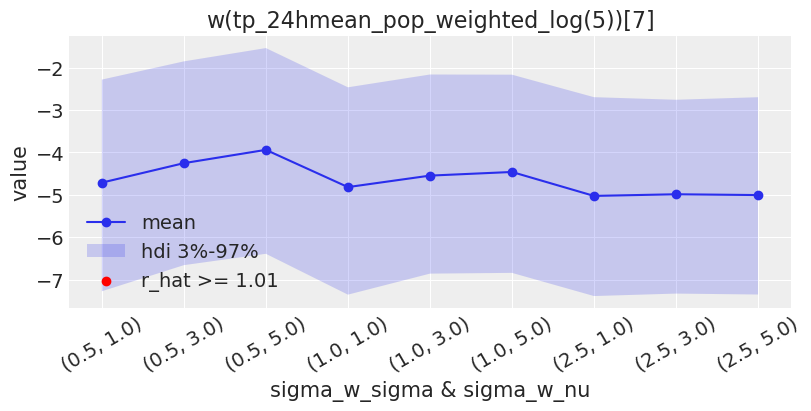

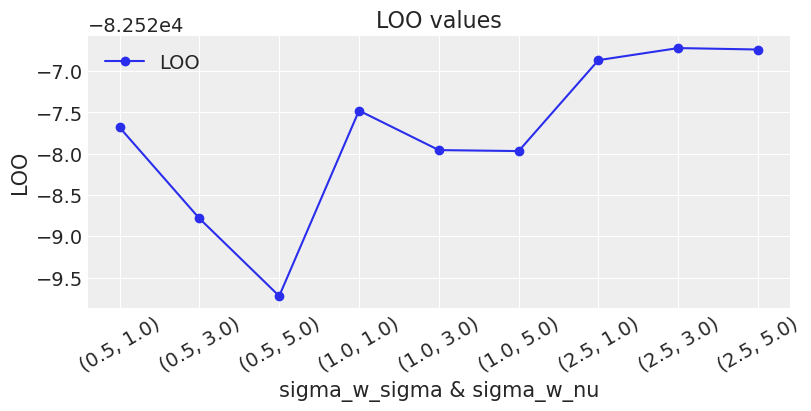

In [30]:
df, loo_df, compare_df, figs = collect_and_plot_outputs(folder + "model_fits/a2_201601_201912[sigma_w_prior_halft]/", "tp_24hmean_log_p(5)", pars=["sigma_w_sigma", "sigma_w_nu"])
display(compare_df)
for fig in figs:
    display(fig)

,rank,loo,p_loo,dloo,weight,loo_se,dse
model,,,,,,,
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_1.0",0,-82613.10,24107,0.00,NaN,315.75,0.00
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_1.0",1,-82613.16,24107,0.06,NaN,315.75,0.05
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_3.0",2,-82613.45,24107,0.35,NaN,315.73,0.28
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_3.0",3,-82613.51,24107,0.41,NaN,315.74,0.28
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_3.0",4,-82613.66,24107,0.56,NaN,315.73,0.36
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_5.0",5,-82614.00,24107,0.91,NaN,315.74,0.63
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_2.5_sigma_w_nu_5.0",6,-82614.01,24107,0.91,NaN,315.74,0.59
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_0.5_sigma_w_nu_5.0",7,-82614.05,24107,0.95,NaN,315.73,0.61
"[nosurv__urb_p_std][t2m_mean_p(0)][3,5,None,no]_sigma_w_sigma_1.0_sigma_w_nu_1.0",8,NaN,24107,NaN,NaN,NaN,NaN


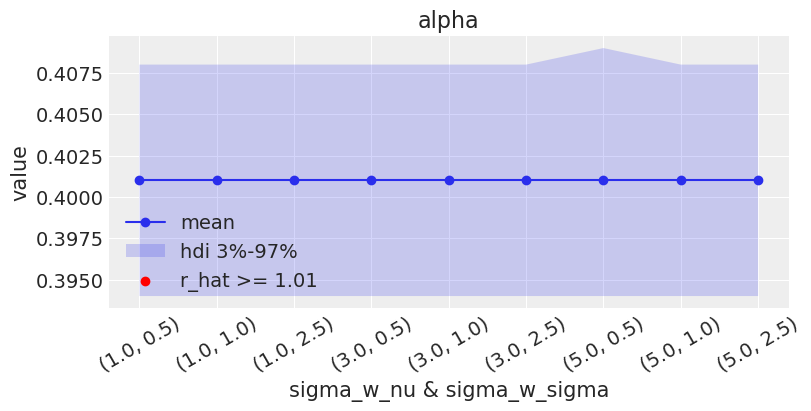

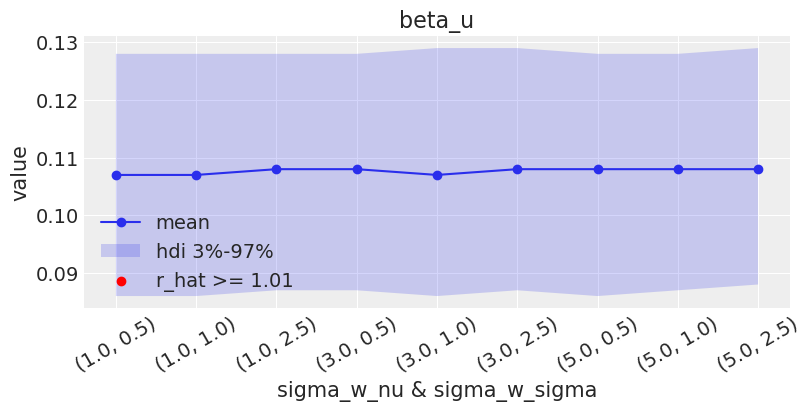

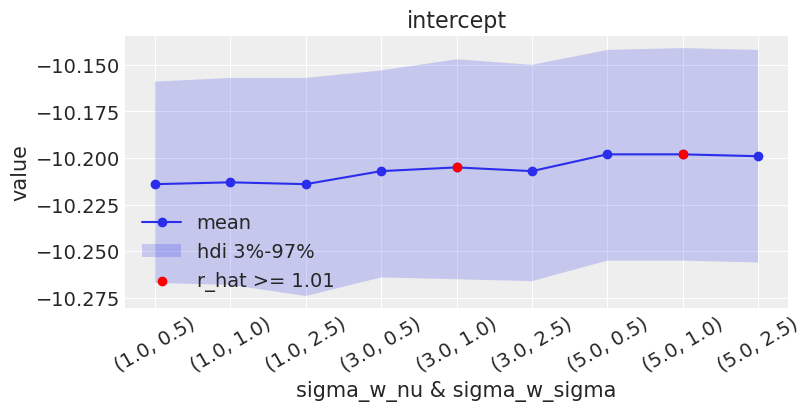

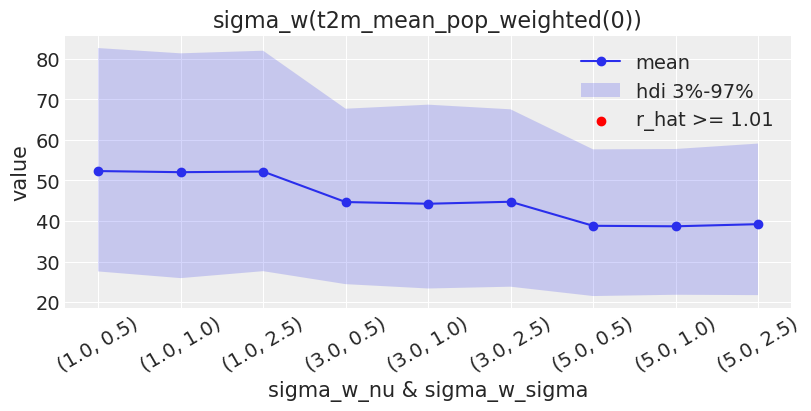

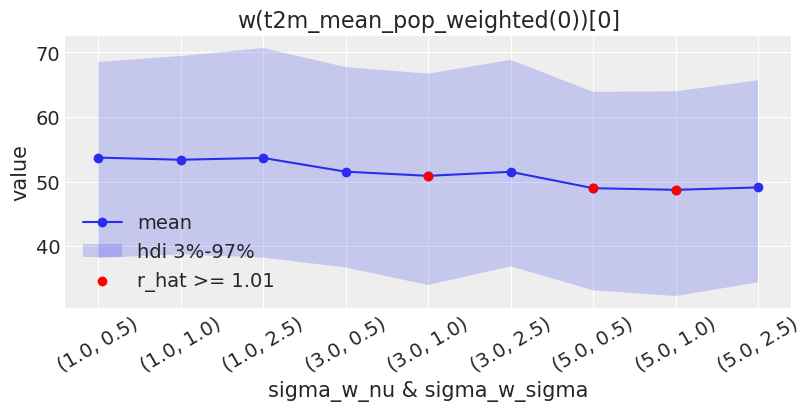

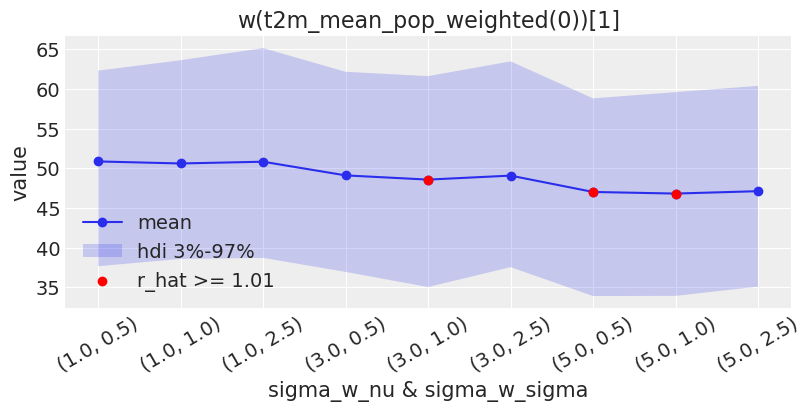

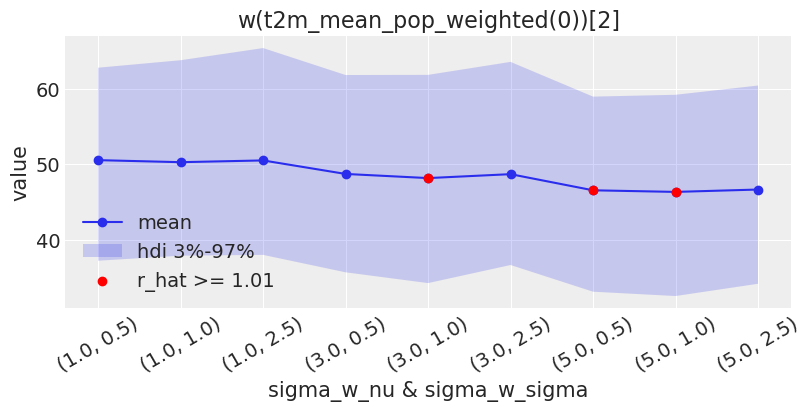

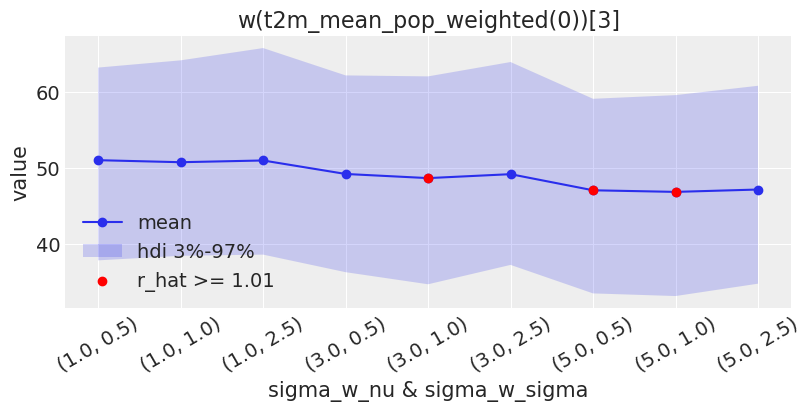

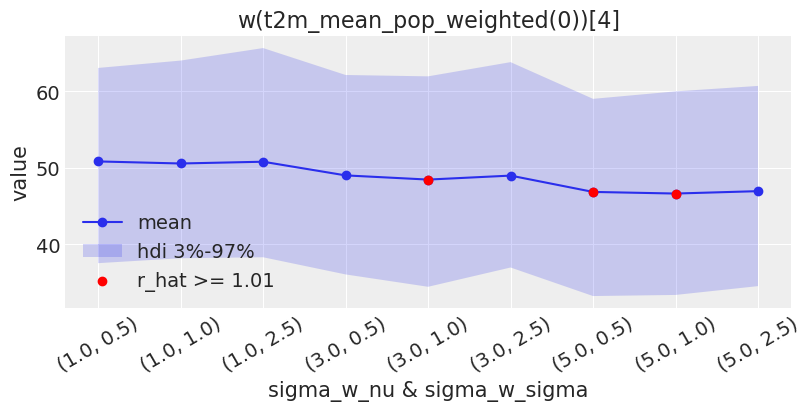

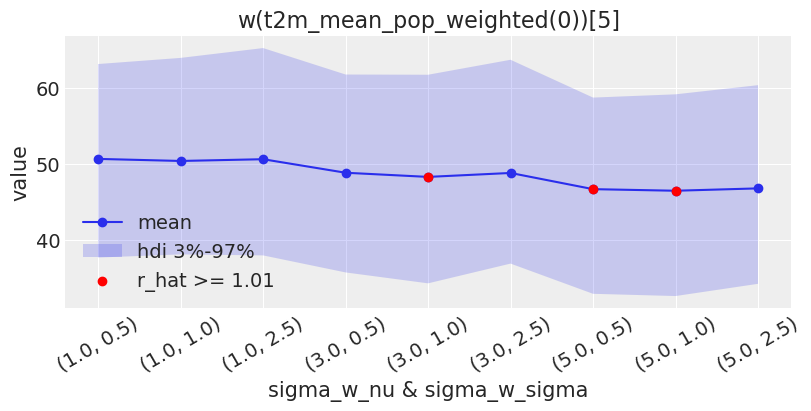

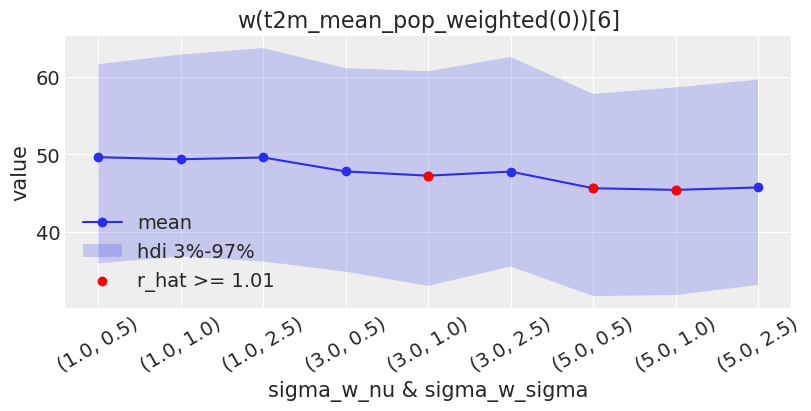

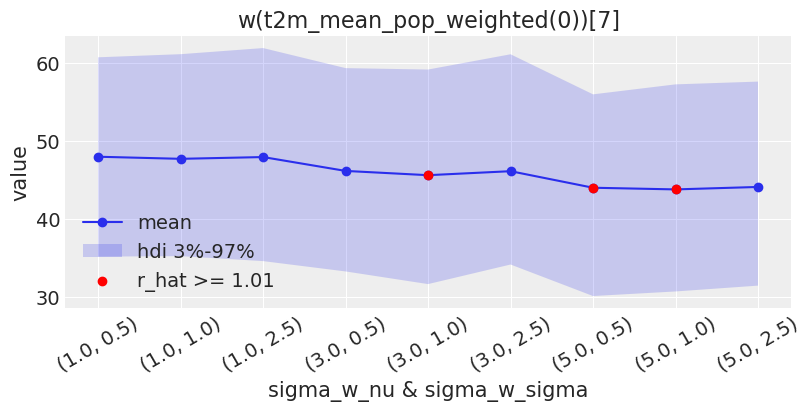

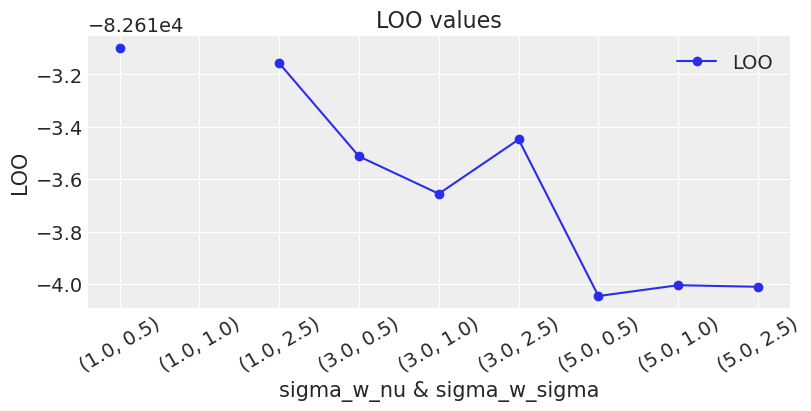

In [31]:
df, loo_df, compare_df, figs = collect_and_plot_outputs(folder + "model_fits/a2_201601_201912[sigma_w_prior_halft]/", "t2m", pars=["sigma_w_nu", "sigma_w_sigma"])
display(compare_df)
for fig in figs:
    display(fig)